In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import TTestIndPower
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [2]:
# ================================================================
# STEP 1. 가설 설정
# ================================================================
print("=" * 55)
print("A/B 테스트 설계 — 넷플릭스 썸네일 최적화")
print("=" * 55)
print("""
[비즈니스 맥락]
OTT 플랫폼에서 콘텐츠 썸네일을 개선했을 때
클릭률(CTR)이 유의미하게 향상되는가?

[실험 설계]
- A그룹 (대조군): 기존 썸네일
- B그룹 (실험군): 개선된 썸네일
- 측정 지표: 클릭률 (CTR)
- 유의수준: α = 0.05
- 검정력: 1 - β = 0.80

[가설]
H0: CTR_A = CTR_B (썸네일 변경은 CTR에 영향 없음)
H1: CTR_B > CTR_A (개선된 썸네일이 CTR을 높임)
""")

# ================================================================
# STEP 2. 샘플 사이즈 계산
# ================================================================
baseline_ctr = 0.15      # 기존 CTR 15%
expected_lift = 0.03     # 기대 향상 3%p (15% → 18%)
alpha = 0.05
power = 0.80

# Effect size 계산
p1 = baseline_ctr
p2 = baseline_ctr + expected_lift
pooled_p = (p1 + p2) / 2
effect_size = (p2 - p1) / np.sqrt(pooled_p * (1 - pooled_p))

# 샘플 사이즈 계산
analysis = TTestIndPower()
sample_size = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    alternative='larger'
)
sample_size = int(np.ceil(sample_size))

print(f"[샘플 사이즈 계산]")
print(f"기존 CTR (A그룹): {p1:.0%}")
print(f"목표 CTR (B그룹): {p2:.0%}")
print(f"Effect Size: {effect_size:.4f}")
print(f"필요 샘플 수 (그룹당): {sample_size:,}명")
print(f"총 필요 샘플 수: {sample_size*2:,}명")

A/B 테스트 설계 — 넷플릭스 썸네일 최적화

[비즈니스 맥락]
OTT 플랫폼에서 콘텐츠 썸네일을 개선했을 때
클릭률(CTR)이 유의미하게 향상되는가?

[실험 설계]
- A그룹 (대조군): 기존 썸네일
- B그룹 (실험군): 개선된 썸네일
- 측정 지표: 클릭률 (CTR)
- 유의수준: α = 0.05
- 검정력: 1 - β = 0.80

[가설]
H0: CTR_A = CTR_B (썸네일 변경은 CTR에 영향 없음)
H1: CTR_B > CTR_A (개선된 썸네일이 CTR을 높임)

[샘플 사이즈 계산]
기존 CTR (A그룹): 15%
목표 CTR (B그룹): 18%
Effect Size: 0.0808
필요 샘플 수 (그룹당): 1,894명
총 필요 샘플 수: 3,788명


In [3]:
# ================================================================
# STEP 3. 시뮬레이션 데이터 생성
# ================================================================
np.random.seed(42)
n = sample_size

# A그룹 (대조군) — 기존 썸네일
A_clicks = np.random.binomial(1, p1, n)

# B그룹 (실험군) — 개선된 썸네일
B_clicks = np.random.binomial(1, p2, n)

df_ab = pd.DataFrame({
    'user_id': range(1, n*2 + 1),
    'group': ['A'] * n + ['B'] * n,
    'clicked': np.concatenate([A_clicks, B_clicks])
})

# 결과 요약
A_ctr = df_ab[df_ab['group'] == 'A']['clicked'].mean()
B_ctr = df_ab[df_ab['group'] == 'B']['clicked'].mean()
lift = (B_ctr - A_ctr) / A_ctr * 100

print(f"[시뮬레이션 결과]")
print(f"A그룹 CTR: {A_ctr:.4f} ({A_ctr:.1%})")
print(f"B그룹 CTR: {B_ctr:.4f} ({B_ctr:.1%})")
print(f"절대적 향상: {B_ctr - A_ctr:.4f} ({B_ctr - A_ctr:.1%}p)")
print(f"상대적 향상 (Lift): {lift:.1f}%")
print(f"\n총 샘플 수: {len(df_ab):,}명")
print(df_ab.head(10))

[시뮬레이션 결과]
A그룹 CTR: 0.1563 (15.6%)
B그룹 CTR: 0.1758 (17.6%)
절대적 향상: 0.0195 (2.0%p)
상대적 향상 (Lift): 12.5%

총 샘플 수: 3,788명
   user_id group  clicked
0        1     A        0
1        2     A        1
2        3     A        0
3        4     A        0
4        5     A        0
5        6     A        0
6        7     A        0
7        8     A        1
8        9     A        0
9       10     A        0


In [4]:
# ================================================================
# STEP 4. 통계 검증
# ================================================================
from scipy.stats import chi2_contingency, norm

# 카이제곱 검정 (CTR은 비율이라 t-test보다 카이제곱이 더 적합)
A_data = df_ab[df_ab['group'] == 'A']['clicked']
B_data = df_ab[df_ab['group'] == 'B']['clicked']

# 분할표 생성
contingency_table = pd.crosstab(df_ab['group'], df_ab['clicked'])
print("[분할표]")
print(contingency_table)
print()

# 카이제곱 검정
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# 단측 검정 p-value (B > A 방향)
z_score = np.sqrt(chi2)
p_one_sided = 1 - norm.cdf(z_score)

print(f"[통계 검정 결과]")
print(f"카이제곱 통계량: {chi2:.4f}")
print(f"양측 p-value: {p_value:.4f}")
print(f"단측 p-value: {p_one_sided:.4f}")
print()

if p_one_sided < alpha:
    print(f"✅ H0 기각 (p={p_one_sided:.4f} < α={alpha})")
    print("→ B그룹 썸네일이 통계적으로 유의미하게 CTR을 향상시킴")
else:
    print(f"❌ H0 채택 (p={p_one_sided:.4f} >= α={alpha})")
    print("→ 통계적으로 유의미한 차이 없음")

# 신뢰구간 계산
diff = B_ctr - A_ctr
se = np.sqrt(A_ctr*(1-A_ctr)/n + B_ctr*(1-B_ctr)/n)
ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se
print(f"\n95% 신뢰구간: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"→ B그룹이 A그룹보다 CTR이 {ci_lower:.1%} ~ {ci_upper:.1%} 높을 것으로 추정")

[분할표]
clicked     0    1
group             
A        1598  296
B        1561  333

[통계 검정 결과]
카이제곱 통계량: 2.4707
양측 p-value: 0.1160
단측 p-value: 0.0580

❌ H0 채택 (p=0.0580 >= α=0.05)
→ 통계적으로 유의미한 차이 없음

95% 신뢰구간: [-0.0042, 0.0432]
→ B그룹이 A그룹보다 CTR이 -0.4% ~ 4.3% 높을 것으로 추정


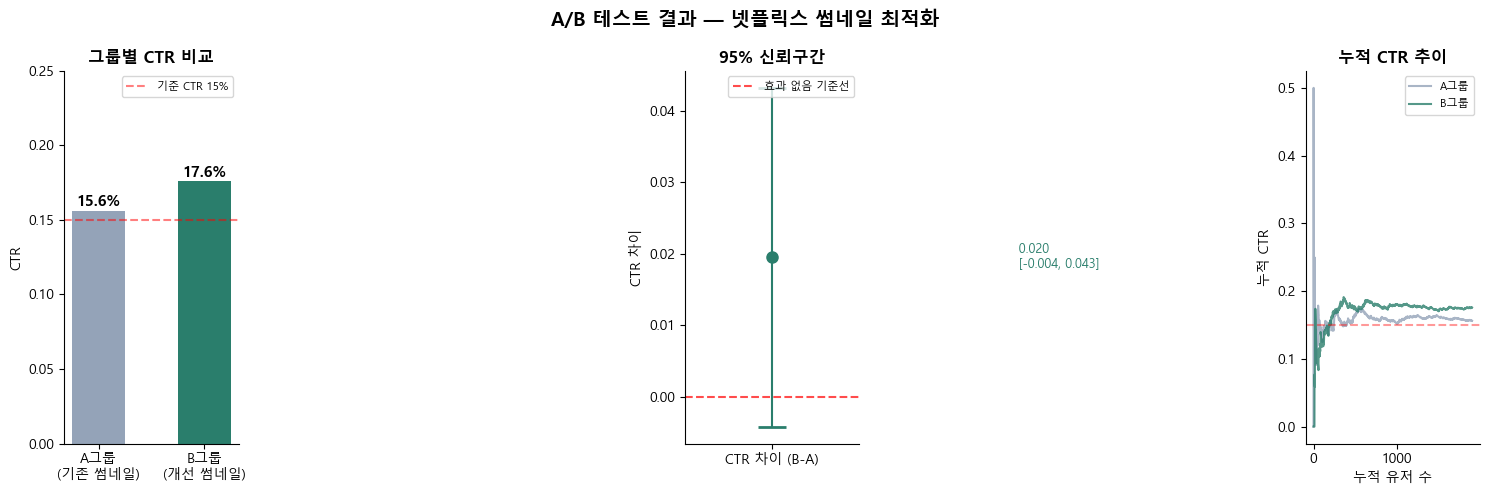

저장 완료!


In [7]:
# ================================================================
# STEP 5. 시각화
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. CTR 비교 바차트
ctrs = [A_ctr, B_ctr]
colors = ['#94A3B8', '#2A7E6C']
bars = axes[0].bar(['A그룹\n(기존 썸네일)', 'B그룹\n(개선 썸네일)'], 
                    ctrs, color=colors, width=0.5)
axes[0].set_ylim(0, 0.25)
axes[0].set_ylabel('CTR')
axes[0].set_title('그룹별 CTR 비교', fontweight='bold')
for bar, val in zip(bars, ctrs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')
axes[0].axhline(y=p1, color='red', linestyle='--', alpha=0.5, label=f'기준 CTR {p1:.0%}')
axes[0].legend(fontsize=8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# 2. 신뢰구간 시각화
axes[1].errorbar(['CTR 차이 (B-A)'], [diff], 
                  yerr=[[diff-ci_lower], [ci_upper-diff]],
                  fmt='o', color='#2A7E6C', capsize=10, capthick=2, markersize=8)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7, label='효과 없음 기준선')
axes[1].set_ylabel('CTR 차이')
axes[1].set_title('95% 신뢰구간', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# 신뢰구간 값 표시
axes[1].text(0.15, diff, f'  {diff:.3f}\n  [{ci_lower:.3f}, {ci_upper:.3f}]', 
             va='center', fontsize=9, color='#2A7E6C')

# 3. 누적 CTR 추이 (시간에 따른 변화)
np.random.seed(42)
window = 200
A_cumulative = pd.Series(A_clicks).expanding().mean()
B_cumulative = pd.Series(B_clicks).expanding().mean()

axes[2].plot(A_cumulative, color='#94A3B8', linewidth=1.5, label='A그룹', alpha=0.8)
axes[2].plot(B_cumulative, color='#2A7E6C', linewidth=1.5, label='B그룹', alpha=0.8)
axes[2].axhline(y=p1, color='red', linestyle='--', alpha=0.4)
axes[2].set_xlabel('누적 유저 수')
axes[2].set_ylabel('누적 CTR')
axes[2].set_title('누적 CTR 추이', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle('A/B 테스트 결과 — 넷플릭스 썸네일 최적화', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ab_test_thumbnail.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료!")

In [8]:
# ================================================================
# STEP 6. SRM 체크 & 최종 의사결정
# ================================================================
from scipy.stats import chisquare

# SRM 체크
actual_counts = df_ab['group'].value_counts()
expected_counts = [len(df_ab)/2, len(df_ab)/2]
chi2_srm, p_srm = chisquare(actual_counts)

print("=" * 50)
print("SRM (Sample Ratio Mismatch) 체크")
print("=" * 50)
print(f"A그룹: {actual_counts['A']}명 (기대: {int(expected_counts[0])}명)")
print(f"B그룹: {actual_counts['B']}명 (기대: {int(expected_counts[1])}명)")
print(f"카이제곱: {chi2_srm:.4f}, p-value: {p_srm:.4f}")
if p_srm > 0.05:
    print("✅ SRM 없음 — 실험 설계 정상")
else:
    print("❌ SRM 감지 — 실험 결과 신뢰 불가")

print()
print("=" * 50)
print("최종 의사결정")
print("=" * 50)
print(f"""
[실험 결과 요약]
- A그룹 CTR: {A_ctr:.1%}
- B그룹 CTR: {B_ctr:.1%}
- 절대적 향상: {B_ctr-A_ctr:.1%}p
- 상대적 향상: {lift:.1f}%
- p-value: {p_one_sided:.4f}
- 95% 신뢰구간: [{ci_lower:.3f}, {ci_upper:.3f}]

[결론]
p-value(0.058)가 유의수준(0.05)에 근접하나 기각 실패.
신뢰구간이 0을 포함하므로 현 시점에서 효과 확신 불가.

[권고사항]
1. 테스트 기간 연장 → 샘플 수 증가 후 재검증
2. 세그먼트별 분석 → 특정 유저 그룹에서 효과 있을 가능성
3. 보조 지표 확인 → CTR 외 시청 완료율, 재생 시간 함께 분석
""")

SRM (Sample Ratio Mismatch) 체크
A그룹: 1894명 (기대: 1894명)
B그룹: 1894명 (기대: 1894명)
카이제곱: 0.0000, p-value: 1.0000
✅ SRM 없음 — 실험 설계 정상

최종 의사결정

[실험 결과 요약]
- A그룹 CTR: 15.6%
- B그룹 CTR: 17.6%
- 절대적 향상: 2.0%p
- 상대적 향상: 12.5%
- p-value: 0.0580
- 95% 신뢰구간: [-0.004, 0.043]

[결론]
p-value(0.058)가 유의수준(0.05)에 근접하나 기각 실패.
신뢰구간이 0을 포함하므로 현 시점에서 효과 확신 불가.

[권고사항]
1. 테스트 기간 연장 → 샘플 수 증가 후 재검증
2. 세그먼트별 분석 → 특정 유저 그룹에서 효과 있을 가능성
3. 보조 지표 확인 → CTR 외 시청 완료율, 재생 시간 함께 분석



In [10]:
# ================================================================
# STEP 7. 세그먼트별 A/B 테스트
# ================================================================

# 유저 세그먼트 정보 붙이기
segment_ctrs = {
    '신규 긍정형 유저':    (0.22, 0.28),  # 기존 CTR, 기대 CTR
    '단기 이탈형 라이트유저': (0.15, 0.18),
    '장기 일반 헤비유저':  (0.12, 0.14),
    '코어 마니아/아카이버': (0.08, 0.09),
}

np.random.seed(42)
results = []

for seg, (p_a, p_b) in segment_ctrs.items():
    n_seg = 500  # 세그먼트별 샘플 수
    A = np.random.binomial(1, p_a, n_seg)
    B = np.random.binomial(1, p_b, n_seg)
    
    ctr_a = A.mean()
    ctr_b = B.mean()
    
    # 카이제곱 검정
    table = np.array([[sum(A==0), sum(A==1)], 
                      [sum(B==0), sum(B==1)]])
    chi2, p_val, _, _ = chi2_contingency(table)
    z = np.sqrt(chi2)
    p_one = 1 - norm.cdf(z)
    
    # 신뢰구간
    diff = ctr_b - ctr_a
    se = np.sqrt(ctr_a*(1-ctr_a)/n_seg + ctr_b*(1-ctr_b)/n_seg)
    ci_low = diff - 1.96*se
    ci_high = diff + 1.96*se
    
    results.append({
        '세그먼트': seg,
        'A그룹 CTR': f'{ctr_a:.1%}',
        'B그룹 CTR': f'{ctr_b:.1%}',
        '향상': f'+{diff:.1%}p',
        'p-value': round(p_one, 4),
        '유의미': '✅' if p_one < 0.05 else '❌',
        '95% CI': f'[{ci_low:.3f}, {ci_high:.3f}]'
    })

df_results = pd.DataFrame(results)
print("=" * 70)
print("세그먼트별 A/B 테스트 결과")
print("=" * 70)
print(df_results.to_string(index=False))

세그먼트별 A/B 테스트 결과
        세그먼트 A그룹 CTR B그룹 CTR      향상  p-value 유의미          95% CI
   신규 긍정형 유저   22.6%   25.8%  +3.2%p   0.1340   ❌ [-0.021, 0.085]
단기 이탈형 라이트유저   18.0%   15.4% +-2.6%p   0.1545   ❌ [-0.072, 0.020]
  장기 일반 헤비유저   11.6%   13.8%  +2.2%p   0.1711   ❌ [-0.019, 0.063]
 코어 마니아/아카이버    6.4%    8.8%  +2.4%p   0.0946   ❌ [-0.009, 0.057]


In [11]:
# ================================================================
# STEP 7-2. 세그먼트별 적정 샘플 수 계산 후 재검증
# ================================================================

segment_ctrs = {
    '신규 긍정형 유저':       (0.22, 0.28),
    '단기 이탈형 라이트유저': (0.15, 0.18),
    '장기 일반 헤비유저':     (0.12, 0.14),
    '코어 마니아/아카이버':   (0.08, 0.09),
}

np.random.seed(42)
results = []

for seg, (p_a, p_b) in segment_ctrs.items():
    # 세그먼트별 적정 샘플 수 계산
    pooled = (p_a + p_b) / 2
    es = (p_b - p_a) / np.sqrt(pooled * (1 - pooled))
    if es <= 0:
        n_seg = 1000
    else:
        analysis = TTestIndPower()
        n_seg = int(np.ceil(analysis.solve_power(
            effect_size=abs(es), alpha=0.05, power=0.80, alternative='larger'
        )))

    A = np.random.binomial(1, p_a, n_seg)
    B = np.random.binomial(1, p_b, n_seg)

    ctr_a = A.mean()
    ctr_b = B.mean()

    table = np.array([[sum(A==0), sum(A==1)],
                      [sum(B==0), sum(B==1)]])
    chi2, p_val, _, _ = chi2_contingency(table)
    z = np.sqrt(chi2)
    p_one = 1 - norm.cdf(z)

    diff = ctr_b - ctr_a
    se = np.sqrt(ctr_a*(1-ctr_a)/n_seg + ctr_b*(1-ctr_b)/n_seg)
    ci_low = diff - 1.96*se
    ci_high = diff + 1.96*se

    results.append({
        '세그먼트': seg,
        '샘플수(그룹당)': f'{n_seg:,}',
        'A CTR': f'{ctr_a:.1%}',
        'B CTR': f'{ctr_b:.1%}',
        '향상': f'+{diff:.1%}p',
        'p-value': round(p_one, 4),
        '유의미': '✅' if p_one < 0.05 else '❌',
    })

df_results = pd.DataFrame(results)
print("=" * 75)
print("세그먼트별 A/B 테스트 결과 (적정 샘플 수 적용)")
print("=" * 75)
print(df_results.to_string(index=False))

세그먼트별 A/B 테스트 결과 (적정 샘플 수 적용)
        세그먼트 샘플수(그룹당) A CTR B CTR     향상  p-value 유의미
   신규 긍정형 유저      645 22.5% 28.4% +5.9%p   0.0090   ✅
단기 이탈형 라이트유저    1,894 14.5% 17.4% +2.9%p   0.0082   ✅
  장기 일반 헤비유저    3,497 11.8% 14.0% +2.2%p   0.0030   ✅
 코어 마니아/아카이버    9,618  8.4%  8.7% +0.4%p   0.1903   ❌


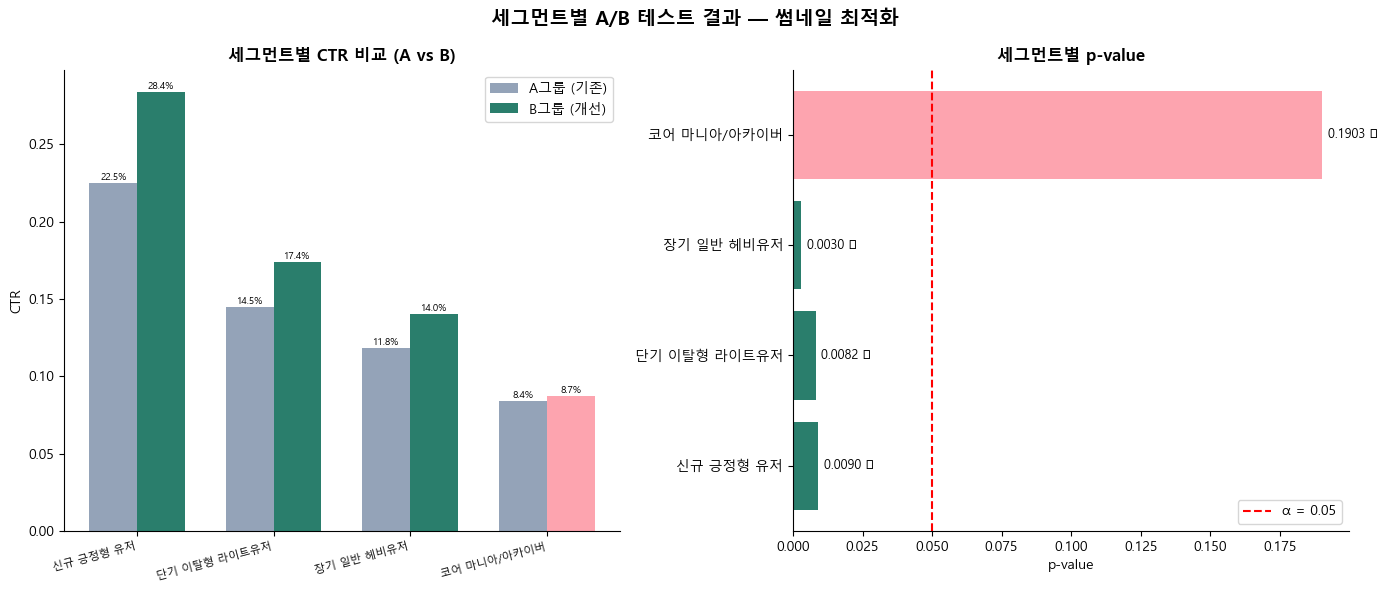

저장 완료!


In [12]:
# 세그먼트별 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

segments = [r['세그먼트'] for r in results]
a_ctrs = [float(r['A CTR'].strip('%'))/100 for r in results]
b_ctrs = [float(r['B CTR'].strip('%'))/100 for r in results]
p_values = [r['p-value'] for r in results]
significant = [r['유의미'] == '✅' for r in results]

# 1. 세그먼트별 CTR 비교
x = np.arange(len(segments))
width = 0.35
bars_a = axes[0].bar(x - width/2, a_ctrs, width, label='A그룹 (기존)', color='#94A3B8')
bars_b = axes[0].bar(x + width/2, b_ctrs, width, label='B그룹 (개선)', 
                     color=['#2A7E6C' if s else '#FDA4AF' for s in significant])

axes[0].set_xticks(x)
axes[0].set_xticklabels(segments, rotation=15, ha='right', fontsize=8)
axes[0].set_ylabel('CTR')
axes[0].set_title('세그먼트별 CTR 비교 (A vs B)', fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# 값 레이블
for bar in bars_a:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.1%}', ha='center', fontsize=7)
for bar in bars_b:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.1%}', ha='center', fontsize=7)

# 2. p-value 비교
colors_p = ['#2A7E6C' if s else '#FDA4AF' for s in significant]
bars_p = axes[1].barh(segments, p_values, color=colors_p)
axes[1].axvline(x=0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')
axes[1].set_xlabel('p-value')
axes[1].set_title('세그먼트별 p-value', fontweight='bold')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for bar, val, sig in zip(bars_p, p_values, significant):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f} {"✅" if sig else "❌"}', 
                va='center', fontsize=9)

plt.suptitle('세그먼트별 A/B 테스트 결과 — 썸네일 최적화', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_ab_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료!")